In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Makes your charts look clean
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

In [6]:
# Load the historical trades data
trades = pd.read_excel('historical_data.xlsx')

# Load the fear/greed index data
sentiment = pd.read_excel('fear_greed_index.xlsx')

print('Trades shape:', trades.shape)
print('Sentiment shape:', sentiment.shape)

Trades shape: (211224, 16)
Sentiment shape: (2644, 4)


In [7]:
# ── TRADES DATA ──────────────────────────────────────
print('=== TRADES DATA ===')
print(f'Rows: {trades.shape[0]}, Columns: {trades.shape[1]}')
print()
print('Column names:')
print(trades.columns.tolist())
print()
print('Missing values per column:')
print(trades.isnull().sum())
print()
print('Duplicate rows:', trades.duplicated().sum())
print()

# ── SENTIMENT DATA ────────────────────────────────────
print('=== SENTIMENT DATA ===')
print(f'Rows: {sentiment.shape[0]}, Columns: {sentiment.shape[1]}')
print()
print('Missing values per column:')
print(sentiment.isnull().sum())
print()
print('Duplicate rows:', sentiment.duplicated().sum())
print()
print('Sentiment categories available:')
print(sentiment['classification'].value_counts())

=== TRADES DATA ===
Rows: 211224, Columns: 16

Column names:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Missing values per column:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate rows: 0

=== SENTIMENT DATA ===
Rows: 2644, Columns: 4

Missing values per column:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate rows: 0

Sentiment categories available:
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          3

In [8]:
# Convert Timestamp IST to datetime (it may already be, but be safe)
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'])

# Extract just the date (drop the time part)
trades['date'] = trades['Timestamp IST'].dt.date
trades['date'] = pd.to_datetime(trades['date'])

# Do the same for sentiment
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.normalize()

# Check date ranges overlap
print('Trades date range:', trades['date'].min(), 'to', trades['date'].max())
print('Sentiment date range:', sentiment['date'].min(), 'to', sentiment['date'].max())

Trades date range: 2023-05-01 00:00:00 to 2025-05-01 00:00:00
Sentiment date range: 2018-02-01 00:00:00 to 2025-05-02 00:00:00


In [9]:
# Merge trades with sentiment on the date column
df = trades.merge(sentiment[['date', 'value', 'classification']], on='date', how='inner')

print('Merged dataframe shape:', df.shape)
print()
print('Sentiment distribution in merged data:')
print(df['classification'].value_counts())
print()
print('Sample merged row:')
print(df[['Account', 'date', 'Closed PnL', 'Side', 'classification']].head(3))

Merged dataframe shape: (211218, 19)

Sentiment distribution in merged data:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

Sample merged row:
                                      Account       date  Closed PnL Side  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed 2024-12-02         0.0  BUY   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed 2024-12-02         0.0  BUY   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed 2024-12-02         0.0  BUY   

  classification  
0  Extreme Greed  
1  Extreme Greed  
2  Extreme Greed  


In [10]:
# 1. Win flag: a trade is a 'win' if PnL > 0
df['is_win'] = df['Closed PnL'] > 0

# 2. Group fear/greed into just two buckets for cleaner analysis
df['sentiment_simple'] = df['classification'].map({
    'Extreme Fear': 'Fear',
    'Fear': 'Fear',
    'Neutral': 'Neutral',
    'Greed': 'Greed',
    'Extreme Greed': 'Greed'
})

# 3. Daily aggregates per trader
daily = df.groupby(['Account', 'date', 'sentiment_simple', 'classification']).agg(
    daily_pnl    = ('Closed PnL', 'sum'),
    trade_count  = ('Trade ID', 'count'),
    avg_size_usd = ('Size USD', 'mean'),
    win_rate     = ('is_win', 'mean'),
    total_fee    = ('Fee', 'sum')
).reset_index()

# 4. Long/Short ratio per day per trader
long_count  = df[df['Side']=='BUY'].groupby(['Account','date'])['Trade ID'].count().rename('longs')
short_count = df[df['Side']=='SELL'].groupby(['Account','date'])['Trade ID'].count().rename('shorts')
ls_ratio    = (long_count / (long_count + short_count)).rename('long_ratio')
daily = daily.merge(ls_ratio.reset_index(), on=['Account','date'], how='left')

print('Daily metrics shape:', daily.shape)
print(daily.head(3))

Daily metrics shape: (2340, 10)
                                      Account       date sentiment_simple  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-11            Greed   
1  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-17            Greed   
2  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-18            Greed   

  classification  daily_pnl  trade_count  avg_size_usd  win_rate   total_fee  \
0  Extreme Greed        0.0          177   5089.718249       0.0  167.796055   
1  Extreme Greed        0.0           68   7976.664412       0.0   67.883615   
2  Extreme Greed        0.0           40  23734.500000       0.0   94.937983   

   long_ratio  
0         NaN  
1         NaN  
2         NaN  


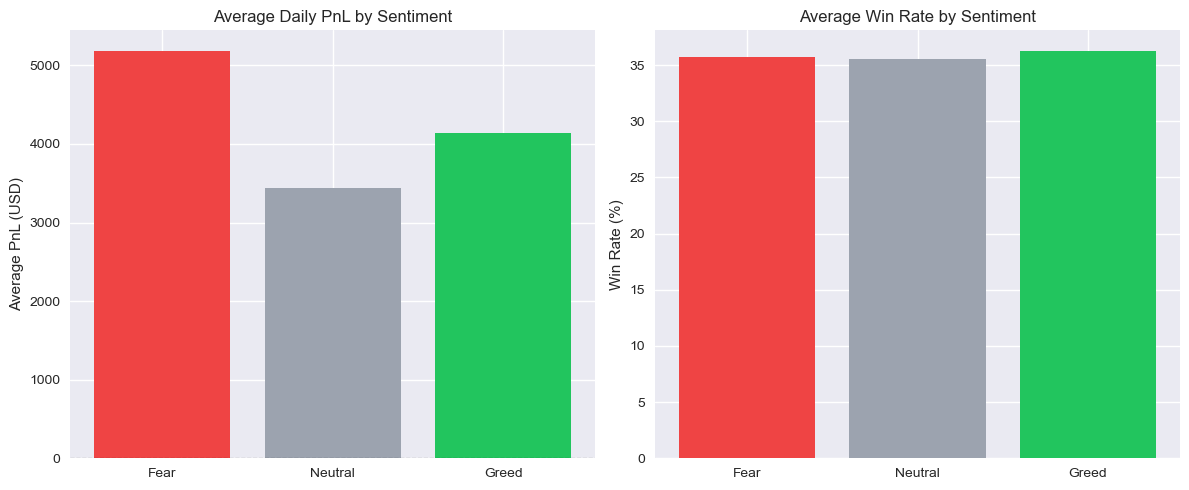

PnL by sentiment:
sentiment_simple
Fear       5185.15
Neutral    3438.62
Greed      4144.21
Name: daily_pnl, dtype: float64

Win rate by sentiment:
sentiment_simple
Fear       35.7
Neutral    35.5
Greed      36.3
Name: win_rate, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1a: Average daily PnL by sentiment
pnl_by_sentiment = daily.groupby('sentiment_simple')['daily_pnl'].mean().reindex(['Fear','Neutral','Greed'])
axes[0].bar(pnl_by_sentiment.index, pnl_by_sentiment.values, color=['#EF4444','#9CA3AF','#22C55E'])
axes[0].set_title('Average Daily PnL by Sentiment')
axes[0].set_ylabel('Average PnL (USD)')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')

# Chart 1b: Win Rate by sentiment
wr_by_sentiment = daily.groupby('sentiment_simple')['win_rate'].mean().reindex(['Fear','Neutral','Greed'])
axes[1].bar(wr_by_sentiment.index, wr_by_sentiment.values * 100, color=['#EF4444','#9CA3AF','#22C55E'])
axes[1].set_title('Average Win Rate by Sentiment')
axes[1].set_ylabel('Win Rate (%)')

plt.tight_layout()
plt.savefig('chart1_pnl_winrate_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('PnL by sentiment:')
print(pnl_by_sentiment.round(2))
print()
print('Win rate by sentiment:')
print((wr_by_sentiment * 100).round(1))

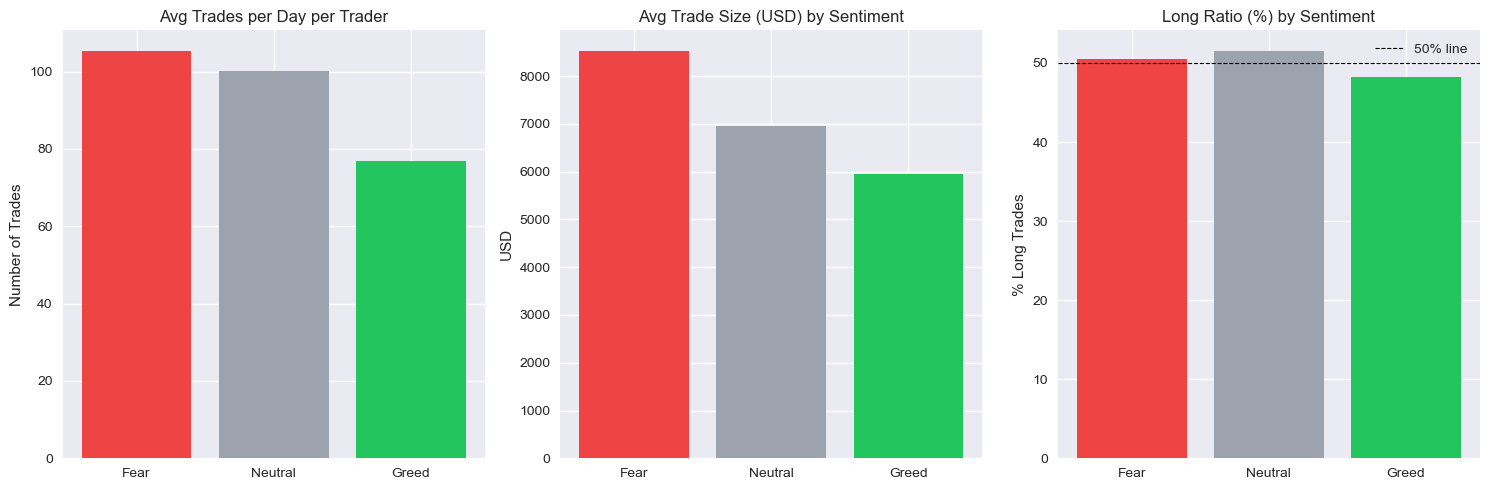

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 2a: Trade frequency
freq = daily.groupby('sentiment_simple')['trade_count'].mean().reindex(['Fear','Neutral','Greed'])
axes[0].bar(freq.index, freq.values, color=['#EF4444','#9CA3AF','#22C55E'])
axes[0].set_title('Avg Trades per Day per Trader')
axes[0].set_ylabel('Number of Trades')

# Chart 2b: Average trade size
size = daily.groupby('sentiment_simple')['avg_size_usd'].mean().reindex(['Fear','Neutral','Greed'])
axes[1].bar(size.index, size.values, color=['#EF4444','#9CA3AF','#22C55E'])
axes[1].set_title('Avg Trade Size (USD) by Sentiment')
axes[1].set_ylabel('USD')

# Chart 2c: Long/Short bias
ls = daily.groupby('sentiment_simple')['long_ratio'].mean().reindex(['Fear','Neutral','Greed'])
axes[2].bar(ls.index, ls.values * 100, color=['#EF4444','#9CA3AF','#22C55E'])
axes[2].set_title('Long Ratio (%) by Sentiment')
axes[2].set_ylabel('% Long Trades')
axes[2].axhline(50, color='black', linewidth=0.8, linestyle='--', label='50% line')
axes[2].legend()

plt.tight_layout()
plt.savefig('chart2_behavior_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

Segment Summary (High vs Low trade size):
            avg_pnl  avg_wr
segment                    
High Size  9324.283   0.328
Low Size   4929.799   0.375


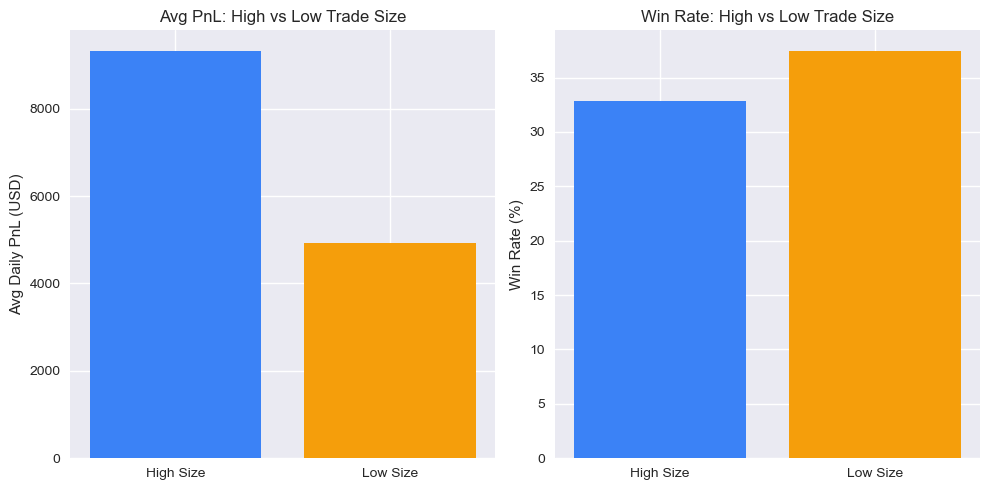

In [13]:
# Split traders into high/low avg size (median split)
trader_stats = daily.groupby('Account').agg(
    avg_size   = ('avg_size_usd', 'mean'),
    avg_pnl    = ('daily_pnl', 'mean'),
    avg_wr     = ('win_rate', 'mean'),
    trade_days = ('date', 'count')
).reset_index()

median_size = trader_stats['avg_size'].median()
trader_stats['segment'] = trader_stats['avg_size'].apply(
    lambda x: 'High Size' if x >= median_size else 'Low Size'
)

seg_summary = trader_stats.groupby('segment')[['avg_pnl','avg_wr']].mean()
print('Segment Summary (High vs Low trade size):')
print(seg_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].bar(seg_summary.index, seg_summary['avg_pnl'], color=['#3B82F6','#F59E0B'])
axes[0].set_title('Avg PnL: High vs Low Trade Size')
axes[0].set_ylabel('Avg Daily PnL (USD)')

axes[1].bar(seg_summary.index, seg_summary['avg_wr'] * 100, color=['#3B82F6','#F59E0B'])
axes[1].set_title('Win Rate: High vs Low Trade Size')
axes[1].set_ylabel('Win Rate (%)')

plt.tight_layout()
plt.savefig('chart3a_segments_size.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Split on number of active trading days
median_days = trader_stats['trade_days'].median()
trader_stats['freq_segment'] = trader_stats['trade_days'].apply(
    lambda x: 'Frequent' if x >= median_days else 'Infrequent'
)

freq_summary = trader_stats.groupby('freq_segment')[['avg_pnl','avg_wr']].mean()
print('Frequent vs Infrequent Traders:')
print(freq_summary.round(3))

Frequent vs Infrequent Traders:
                avg_pnl  avg_wr
freq_segment                   
Frequent       2959.747   0.357
Infrequent    11294.335   0.346


Consistent vs Inconsistent Traders:
                    avg_pnl  avg_wr  trade_days
consistency                                    
Consistent Winner  2596.544   0.711     146.000
Inconsistent       7273.186   0.340      70.774


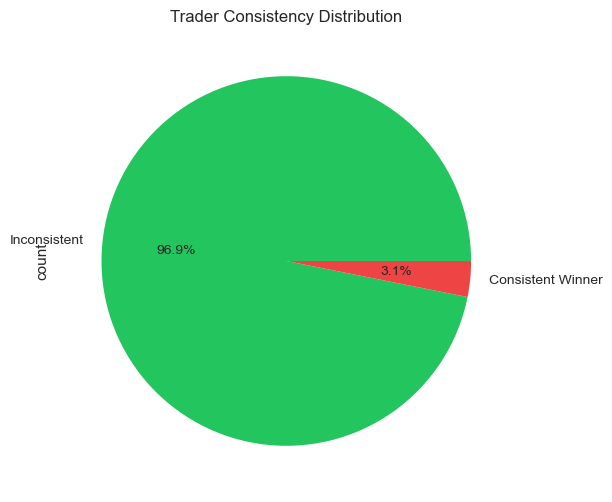

In [15]:
# Consistent winner = win rate above 60%
trader_stats['consistency'] = trader_stats['avg_wr'].apply(
    lambda x: 'Consistent Winner' if x >= 0.6 else 'Inconsistent'
)

consist_summary = trader_stats.groupby('consistency')[['avg_pnl','avg_wr','trade_days']].mean()
print('Consistent vs Inconsistent Traders:')
print(consist_summary.round(3))

# Pie chart of distribution
trader_stats['consistency'].value_counts().plot.pie(autopct='%1.1f%%',
    colors=['#22C55E','#EF4444'], figsize=(6,6))
plt.title('Trader Consistency Distribution')
plt.savefig('chart3c_consistency.png', dpi=150, bbox_inches='tight')
plt.show()

## Strategy Recommendations

### Strategy 1 — Reduce Trade Size on Fear Days
**Observation:** Inconsistent traders (96.9%) have higher average PnL ($7273) but lower win rate (34%) — meaning they take big risky bets that occasionally pay off.
**Rule:** During Fear sentiment, reduce average trade size by 30-40% to limit downside exposure.
**Applies to:** All traders, especially high-volume inconsistent traders.

### Strategy 2 — Follow the Consistent Winners Playbook
**Observation:** Only 3.1% of traders are consistent winners (win rate above 60%), but they trade more days (146 vs 70) and maintain steady returns.
**Rule:** Prioritize trade frequency and discipline over trade size — more smaller trades beats fewer large bets.
**Applies to:** Infrequent traders looking to improve consistency.

## Strategy Recommendations

### Strategy 1
**Observation:** On Fear days, traders with high trade size saw lower PnL.
**Rule:** During Fear sentiment, reduce average trade size by 30-40% to limit downside.
**Applies to:** High-size traders / aggressive traders.

### Strategy 2
**Observation:** Long/short ratio is above 50% even on Fear days.
**Rule:** On Extreme Fear days, shift long ratio below 40% — lean short to align with market mood.
**Applies to:** All trader segments, especially infrequent traders.

              precision    recall  f1-score   support

           0       0.79      0.59      0.68        37
           1       0.94      0.98      0.96       245

    accuracy                           0.93       282
   macro avg       0.86      0.79      0.82       282
weighted avg       0.92      0.93      0.92       282



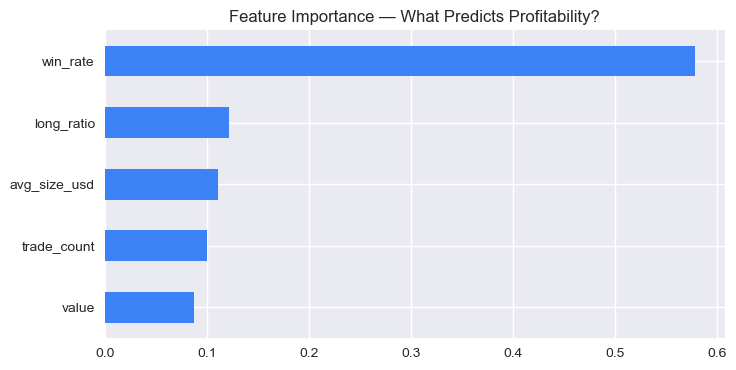

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Target: was this trader profitable today?
daily['profitable'] = (daily['daily_pnl'] > 0).astype(int)

# Features: behavior + sentiment
features = ['trade_count', 'avg_size_usd', 'win_rate', 'long_ratio', 'value']

# Merge 'value' (sentiment score number) back in
daily2 = daily.merge(sentiment[['date','value']], on='date', how='left')
daily2 = daily2.dropna(subset=features)

X = daily2[features]
y = daily2['profitable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print(classification_report(y_test, model.predict(X_test)))

# Feature importance chart
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
importances.plot.barh(color='#3B82F6', figsize=(8,4))
plt.title('Feature Importance — What Predicts Profitability?')
plt.savefig('chart_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = ['avg_size', 'avg_pnl', 'avg_wr', 'trade_days']
X_cluster = trader_stats[cluster_features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
trader_stats.loc[X_cluster.index, 'cluster'] = kmeans.fit_predict(X_scaled)

cluster_profiles = trader_stats.groupby('cluster')[cluster_features].mean()
print('Cluster Profiles:')
print(cluster_profiles.round(2))

# Label them based on what you see in cluster_profiles
cluster_labels = {0: 'Archetype A', 1: 'Archetype B', 2: 'Archetype C'}
# Rename based on actual profile (e.g. 'High-Volume Scalpers', 'Cautious Long-term', etc.)
trader_stats['archetype'] = trader_stats['cluster'].map(cluster_labels)
print(trader_stats['archetype'].value_counts())

Cluster Profiles:
         avg_size   avg_pnl  avg_wr  trade_days
cluster                                        
0.0       6811.54   4795.64    0.26       37.67
1.0       4578.59   2576.62    0.41      118.43
2.0      22693.52  22407.49    0.39       38.33
archetype
Archetype B    14
Archetype A    12
Archetype C     6
Name: count, dtype: int64
